# Import libraries and data

## Libraries and functions

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import networkx as nx
import csv
import xml.etree.ElementTree as ET
from scipy.spatial import KDTree
from scipy.spatial import cKDTree
import pickle
import folium
from shapely.geometry import LineString
from shapely.geometry import box
import contextily as ctx


from Tool import clean_speed, fill_tracks, clean_elec, from_df_to_geodf, neighbour_gauge, final_gauge, haversine_distance, is_important_component, get_stanox_from_bbox, subgraph_by_stanox

## Inputs

In [136]:
#Change inputs here if needed
rail_data = "data/uk_railways_osm.gpkg"
Train_Planning_file = "data/TrainPlanningRules.xml"
Stops = "data/Stops.csv"
loading_gauge = "data/loading_gauge.geojson"
nodes_file = "nodes.csv"
STANOX_TIPLOC = "data/STANOX_TIPLOC.csv"

## Import of the datasets and conversion into a csv file

In [137]:
gdf = gpd.read_file(rail_data)

gdf['geometry_wkt'] = gdf['geometry'].apply(lambda x: x.wkt)

gdf['start_lon'] = gdf['geometry'].apply(lambda x: x.coords[0][0])
gdf['start_lat'] = gdf['geometry'].apply(lambda x: x.coords[0][1])
gdf['end_lon'] = gdf['geometry'].apply(lambda x: x.coords[-1][0])
gdf['end_lat'] = gdf['geometry'].apply(lambda x: x.coords[-1][1])

if 'other_tags' in gdf.columns:
    gdf['other_tags'] = gdf['other_tags'].astype(str)

#Not compatible with geopandas
df_rail = pd.DataFrame(gdf.drop(columns=['geometry']))

df_rail.to_csv("complete_railway_network.csv", index=False, sep=';', encoding='utf-8')

## Clean this dataset

In [138]:
df_rail = df_rail[df_rail['railway'].isin(['rail', 'service', 'yard', 'siding', 'industrial', 'disused'])]

### Clean speed format and fill missing values with 60 mph.

In [139]:
df_rail = clean_speed(df_rail)

### Here, we consider to fill the branch or industrial types with 1 track, the others with 2 tracks.

In [140]:
df_rail = fill_tracks(df_rail)
df_rail["tracks"] = df_rail["tracks"].astype(int)

### We will simplify different type of electrification

In [141]:
df_rail['elec_type'] = df_rail.apply(clean_elec, axis=1)

In [142]:
df_rail.columns

Index(['osm_id', 'name', 'highway', 'waterway', 'aerialway', 'barrier',
       'man_made', 'railway', 'usage', 'electrified', 'frequency', 'gauge',
       'maxspeed', 'operator', 'railway_aws', 'railway_tpws', 'ref', 'voltage',
       'layer', 'tracks', 'passenger_lines', 'foot', 'lit', 'segregated',
       'smoothness', 'surface', 'width', 'bicycle', 'z_order', 'other_tags',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type'],
      dtype='object')

In [143]:
to_drop = [
    "highway", "waterway", "aerialway", "barrier", "man_made",
    "railway_aws", "railway_tpws", "ref", "layer", "foot", "lit",
    "segregated", "smoothness", "surface", "width", "bicycle",
    "z_order", "other_tags"
]

df_rail = df_rail.drop(columns=[c for c in to_drop if c in df_rail.columns])

In [144]:
print("\n Stats for 'electrified':")
print(df_rail['electrified'].value_counts(dropna=False))


 Stats for 'electrified':
electrified
no                       43896
contact_line             26848
rail                     13110
None                      8157
4th_rail                   283
proposed                   242
contact_line;rail          157
contact_line;4th_rail        9
yes                          4
0                            1
construction                 1
Name: count, dtype: int64


In [145]:
df_rail.head()

,osm_id,name,railway,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,passenger_lines,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type
0,740,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead
1,2148,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead
3,3413,North Clyde Line,rail,main,contact_line,50,1435,50.0,Network Rail,25000,2,2,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead
4,3417,North Clyde Line,rail,main,contact_line,50,1435,40.0,Network Rail,25000,2,2,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead
5,3471,Midland Main Line,rail,main,contact_line,50,1435,90.0,Network Rail,25000,1,4,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead


In [146]:
print("Values in 'tracks':")
print(df_rail['tracks'].unique())
print(df_rail['tracks'].value_counts(dropna=False))

Values in 'tracks':
[1 2 4 5 6 3]
tracks
2    67897
1    23266
4     1144
6      301
3       51
5       49
Name: count, dtype: int64


In [147]:
len(df_rail)

92708

# Cleaning of the dataset

## Load the loading gauge dataset

In [148]:
#Load datasets

gdf_rail = from_df_to_geodf(df_rail)
gdf_loading_gauge = gpd.read_file(loading_gauge)

#Join and check the neighbours to apply to missing loading gauges
df_complete = neighbour_gauge(gdf_rail, gdf_loading_gauge)

#If no neighboutrs, check the voltage to find the loading gauge
df_complete['loading_gauge_final'] = df_complete.apply(final_gauge, axis=1)

#Spread of different loading gauges
print(df_complete['loading_gauge_final'].value_counts())

c:\Users\Administrateur\Documents\3A\Internship\resilience_freight_train_UK\Tool.py:92: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  unknown['geom_buffer'] = unknown.geometry.buffer(0.00001)


loading_gauge_final
6.0     51062
10.0    26553
7.0     12538
8.0      1590
12.0      790
1.0       117
9.0        58
Name: count, dtype: int64


## Clean this datset

### Outliers : there are "W1" gauges that need to be removed

In [149]:
#We replace these W1 values by W6 values
df_complete.loc[df_complete['loading_gauge_final'] < 6, 'loading_gauge_final'] = 6
print(df_complete['loading_gauge_final'].value_counts().sort_index())

df_complete.to_csv("Final_dataframe_rail.csv", index=False)

loading_gauge_final
6.0     51179
7.0     12538
8.0      1590
9.0        58
10.0    26553
12.0      790
Name: count, dtype: int64


In [150]:
df_complete = df_complete.drop(columns=['railway', 'index_right', 'loading_gauge_val'])

## Add the distance between two nodes

In [151]:
df_complete['distance'] = haversine_distance(df_complete["start_lat"],df_complete["start_lon"],df_complete["end_lat"],df_complete["end_lon"])
df_complete['min_travel_time'] = df_complete['distance'] / df_complete['maxspeed']

In [152]:
df_complete.head()

,osm_id,name,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,...,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type,geometry,loading_gauge_final,distance,min_travel_time
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346
3,3413,North Clyde Line,main,contact_line,50,1435,50.0,Network Rail,25000,2,...,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead,"LINESTRING (-4.32588 55.88272, -4.32559 55.882...",10.0,0.110298,0.002206
4,3417,North Clyde Line,main,contact_line,50,1435,40.0,Network Rail,25000,2,...,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead,"LINESTRING (-4.31389 55.87767, -4.31399 55.876...",10.0,0.482767,0.012069
5,3471,Midland Main Line,main,contact_line,50,1435,90.0,Network Rail,25000,1,...,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead,"LINESTRING (-0.49508 51.96812, -0.49519 51.96374)",10.0,0.302781,0.003364


## Upload a file with names for train stations

In [153]:
with open(nodes_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "tiploc", "name"])

    for event, elem in ET.iterparse(Train_Planning_file, events=("end",)):
        if elem.tag == "TTPRLocation":
            
            writer.writerow([
                elem.attrib.get("Id"),
                elem.attrib.get("Tiploc"),
                elem.attrib.get("Description")
            ])
            
            elem.clear()

## Clean this dataset

In [154]:
df_nodes = pd.read_csv(nodes_file)

#Delete row without ID
df_nodes = df_nodes.dropna(subset=['id'])
df_nodes = df_nodes.drop_duplicates()

#Clean the str and make sure any blank space is there
df_nodes['tiploc'] = df_nodes['tiploc'].astype(str).str.strip()
df_nodes['name'] = df_nodes['name'].astype(str).str.strip()

invalid_values = ["unknown", "none", "nan"]

df_nodes = df_nodes[
    ~df_nodes.drop(columns=["id"])
      .apply(lambda col: col.astype(str).str.strip().str.lower())
      .isin(invalid_values)
      .all(axis=1)
]


df_nodes.to_csv("nodes_clean.csv", index=False)

print("Number of remaining nodes: ", len(df_nodes))

Number of remaining nodes:  12107


In [155]:
df_nodes.head()

,id,tiploc,name
2,3.0,AACHEN,Aachen
3,4.0,ABCWM,Abercwmboi
4,5.0,ABDAPEN,Penywaun
5,6.0,ABDARE,Aberdare
6,7.0,ABDATRE,Trecynon


## Load datsaset with locations and merge with the names dataset

In [156]:
df_lon_lat = pd.read_csv("data/stations.csv")

print("Number of nodes remaining (nodes) : ", len(df_nodes))
print("Number of nodes remaining (lon_lat) : ", len(df_lon_lat))

df_name_loc = pd.merge(
    df_nodes, 
    df_lon_lat, 
    left_on='name', 
    right_on='stationName', 
    how='left'
)

df_name_loc.head(10)

Number of nodes remaining (nodes) :  12107
Number of nodes remaining (lon_lat) :  2605


,id,tiploc,name,stationName,lat,long,crsCode,iataAirportCode,constituentCountry
0,3.0,AACHEN,Aachen,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,ABCWM,Abercwmboi,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,ABDAPEN,Penywaun,NaN,NaN,NaN,NaN,NaN,NaN
3,6.0,ABDARE,Aberdare,Aberdare,51.715019,-3.443130,ABA,NaN,wales
4,7.0,ABDATRE,Trecynon,NaN,NaN,NaN,NaN,NaN,NaN
5,8.0,ABDO,Aberdour,Aberdour,56.054646,-3.300575,AUR,NaN,scotland
6,9.0,ABDVY,Aberdovey,Aberdovey,52.543934,-4.057118,AVY,NaN,wales
7,10.0,ABER,Aber,Aber,51.575363,-3.230890,ABE,NaN,wales
8,11.0,ABGLELE,Abergele & Pensarn,Abergele & Pensarn,53.294758,-3.581343,AGL,NaN,wales
9,12.0,ABGNWYN,Abergynolwyn,NaN,NaN,NaN,NaN,NaN,NaN


In [157]:
print(len(df_name_loc))
df_name_loc = df_name_loc.drop(columns=['stationName', 'iataAirportCode', 'constituentCountry'])

12107


In [158]:
df_name_loc.head()

,id,tiploc,name,lat,long,crsCode
0,3.0,AACHEN,Aachen,NaN,NaN,NaN
1,4.0,ABCWM,Abercwmboi,NaN,NaN,NaN
2,5.0,ABDAPEN,Penywaun,NaN,NaN,NaN
3,6.0,ABDARE,Aberdare,51.715019,-3.44313,ABA
4,7.0,ABDATRE,Trecynon,NaN,NaN,NaN


## Add the Engineer Line Reference (ELR) in order to identify easily the line

In [159]:
elr = gpd.read_file("data/ELR/NetworkReferenceLines.shp")
elr_buff = elr.to_crs(4326).copy()
elr_buff["geometry"] = elr_buff.geometry.buffer(0.0001)
elr


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_20736\2230585469.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  elr_buff["geometry"] = elr_buff.geometry.buffer(0.0001)


,OBJECTID,ASSETID,L_LINK_ID,L_SYSTEM,ELR,L_M_FROM,L_M_TO,SHAPE_LEN,geometry
0,1650,9003000263,232,M,CNC,-0.0055,0.0891,899.318917,"LINESTRING Z (258538.418 661238.192 0, 258545...."
1,1651,9003001307,1191,M,WCL,0.1758,2.1706,3170.461977,"LINESTRING Z (521077.898 183246.059 0, 521052...."
2,1652,9003001178,1076,M,SSK1,26.1589,39.0242,19691.905626,"LINESTRING Z (465068.728 521387.373 0, 465077...."
3,1653,9003001388,1260,M,YJP,-0.0350,1.0954,2797.307199,"LINESTRING Z (356982.337 114059.032 0, 356989...."
4,1654,9003000952,873,M,PEH,0.0849,13.0960,21015.381545,"LINESTRING Z (413793.018 416380.012 0, 413729...."
...,...,...,...,...,...,...,...,...,...
1585,5131,9003001637,1694,M,GRC1,-0.0068,0.0723,732.035182,"LINESTRING Z (441392.094 406550.649 0, 441449...."
1586,5132,9003001623,1680,M,CMP,188.0727,188.1215,446.568578,"LINESTRING Z (385412.469 397552.006 0, 385361...."
1587,5133,9003001609,1718,M,RET,-0.0016,0.0927,863.140513,"LINESTRING Z (193288.191 59949.545 0, 193314.5..."
1588,5134,9003001618,1673,M,SWX,-0.0012,0.0784,728.586613,"LINESTRING Z (503416.196 172077.673 0, 503378...."


In [160]:
df_final = gpd.sjoin(
    df_complete,
    elr_buff[["ELR", "L_LINK_ID", "geometry"]],
    how="left",
    predicate="intersects"
)

print(df_final["ELR"].isna().mean())

print(df_final.columns)
print(df_name_loc.columns)

0.1499253041189443
Index(['osm_id', 'name', 'usage', 'electrified', 'frequency', 'gauge',
       'maxspeed', 'operator', 'voltage', 'tracks', 'passenger_lines',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type', 'geometry', 'loading_gauge_final', 'distance',
       'min_travel_time', 'index_right', 'ELR', 'L_LINK_ID'],
      dtype='object')
Index(['id', 'tiploc', 'name', 'lat', 'long', 'crsCode'], dtype='object')


In [219]:
df_final.to_csv("OSM_cleaned_data.csv", index=False, sep=';', encoding='utf-8')

In [217]:
df_final.head()

,osm_id,name,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,...,end_lon,end_lat,elec_type,geometry,loading_gauge_final,distance,min_travel_time,index_right,ELR,L_LINK_ID
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520,877.0,CBR2,179.0
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520,750.0,ALC2,19.0
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346,497.0,ALC1,18.0
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346,88.0,PBJ,861.0
3,3413,North Clyde Line,main,contact_line,50,1435,50.0,Network Rail,25000,2,...,-4.323074,55.882447,Overhead,"LINESTRING (-4.32588 55.88272, -4.32559 55.882...",10.0,0.110298,0.002206,529.0,YKR,1261.0


# Construction of the graph

In [161]:
G = nx.Graph()

for _, row in df_name_loc.iterrows():

    node_id = row["tiploc"] if pd.notna(row["tiploc"]) else row["id"]

    G.add_node(
        node_id,
        type="station",
        name=row["name"],
        lat=row["lat"],
        lon=row["long"],
        crs=row["crsCode"],
    )

for _, row in df_final.iterrows():

    start = (row.start_lon, row.start_lat)
    end = (row.end_lon, row.end_lat)

    G.add_node(start, type="osm_point", lon=row.start_lon, lat=row.start_lat)
    G.add_node(end, type="osm_point", lon=row.end_lon, lat=row.end_lat)

    G.add_edge(
        start,
        end,
        distance=row["distance"],
        maxspeed=row["maxspeed"],
        loading_gauge=row["loading_gauge_final"],
        electrified=row["elec_type"],
        gauge=row["gauge"],
        tracks=row["tracks"],
        usage=row["usage"],
        elr=row["ELR"]
    )


#We merge the two dataframe into a graph
osm_nodes = np.array([node for node in G.nodes if isinstance(node, tuple)])

for _, row in df_name_loc.iterrows():

    station_id = row["tiploc"] if pd.notna(row["tiploc"]) else row["id"]
    station_point = np.array([row["long"], row["lat"]])

    #We aggregagte the nearest osm node to the tnode station
    dists = np.linalg.norm(osm_nodes - station_point, axis=1)
    nearest = tuple(osm_nodes[np.argmin(dists)])

    G.add_edge(station_id, nearest, type="station_link")


## Add STANOX attributes to the graph

In [162]:
df_STAN_TIP = pd.read_csv("data/STANOX_TIPLOC.csv", sep=",")
df_STAN_TIP["STANOX"] = (
    df_STAN_TIP["STANOX"]
    .astype(str)
    .str.strip()
    .replace("", None)
    .apply(lambda x: x.zfill(5) if x is not None else None)
)

stanox_map = df_STAN_TIP.set_index("TIPLOC")["STANOX"].to_dict()

for n, d in G.nodes(data=True):
    if d.get("type") == "station":
        tiploc = n
        d["stanox"] = stanox_map.get(tiploc)

In [163]:
stations = [n for n, d in G.nodes(data=True) if d.get("type")=="station"]
[(n, G.nodes[n].get("stanox")) for n in stations[:10]]

[('AACHEN', '00005'),
 ('ABCWM', '78128'),
 ('ABDAPEN', None),
 ('ABDARE', '78100'),
 ('ABDATRE', None),
 ('ABDO', '03295'),
 ('ABDVY', '64409'),
 ('ABER', '78371'),
 ('ABGLELE', '40073'),
 ('ABGNWYN', None)]

## Look at the graph attributes

In [164]:
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())


Nodes : 119337
Edges : 104253


In [165]:
stations = [n for n, d in G.nodes(data=True) if d.get("type") == "station"]
print("Stations :", len(stations))


Stations : 11696


### Check whether some parts are isolated

In [166]:
nx.number_connected_components(G)

16874

In [167]:
distances = [d["distance"] for _,_,d in G.edges(data=True) if "distance" in d]
pd.Series(distances).describe()

count    92556.000000
mean         0.248679
std          0.501591
min          0.000000
25%          0.022690
50%          0.080016
75%          0.252066
max         15.837627
dtype: float64

In [168]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
print("Number of components in the graph :", len(components))
print("Size of the largest component :", len(components[0]))

Number of components in the graph : 16874
Size of the largest component : 73648


## Components to reconnect to the network

In [169]:
#Number of components ordered and with more than 20 nodes
components = list(nx.connected_components(G))
components_sorted = sorted(components, key=len, reverse=True)
components_filtered = [c for c in components_sorted if len(c) >= 20]
print(f"Total number of components : {len(components_sorted)}")

#Main component
main_component = components_filtered[0]
main_coords = np.array([n for n in main_component if isinstance(n, tuple)])
main_tree = KDTree(main_coords)

#Check if each component needs to be kept  or rejected
results = []

for idx, comp in enumerate(components_filtered):
    keep = is_important_component(G, comp, stations, main_coords, main_tree)
    results.append((idx, len(comp), keep))

for idx, size, keep in results:
    status = "KEPT" if keep else "REJECTED"

kept = sum(1 for _,_,k in results if k)
print("\nAfter cleaning, we have kept :", kept, "components")

Total number of components : 16874

After cleaning, we have kept : 86 components


## Distribution of node sizes components

In [170]:
sizes_kept = [len(components_filtered[idx]) 
              for idx, _, keep in results if keep]

print("Min size :", np.min(sizes_kept))
print("Max size :", np.max(sizes_kept))
print("Average size :", np.mean(sizes_kept))

hist = {}
for s in sizes_kept:
    bucket = (s // 20) * 20
    hist[bucket] = hist.get(bucket, 0) + 1

print("\nDistribution of remaining components :")
for k in sorted(hist):
    print(f"{k:3d}–{k+19:3d} : {hist[k]}")

Min size : 20
Max size : 73648
Average size : 909.3953488372093

Distribution of remaining components :
 20– 39 : 57
 40– 59 : 19
 60– 79 : 2
 80– 99 : 1
100–119 : 1
120–139 : 2
160–179 : 1
540–559 : 1
780–799 : 1
73640–73659 : 1


## Adding the disconnected components to the main component and linking them

In [171]:
kept_components = [
    comp for idx, comp in enumerate(components_filtered)
    if results[idx][2]
]

In [172]:
G_clean = nx.Graph()

for comp in kept_components:
    for n in comp:
        if isinstance(n, tuple) and len(n) == 2:
            G_clean.add_node(n, **G.nodes[n])

    for u, v in G.subgraph(comp).edges():
        if isinstance(u, tuple) and isinstance(v, tuple):
            G_clean.add_edge(u, v, **G[u][v])

In [173]:
component_trees = []

for idx, comp in enumerate(kept_components):
    coords = np.array([n for n in comp if isinstance(n, tuple)])
    tree = cKDTree(coords)
    component_trees.append((idx, coords, tree))

In [174]:
connections = []

for i, (idx_i, coords_i, tree_i) in enumerate(component_trees):
    for j, (idx_j, coords_j, tree_j) in enumerate(component_trees):
        if j <= i:
            continue

        dist, pos = tree_i.query(coords_j, k=1)
        min_dist = dist.min()

        if min_dist <= 0.2:
            j_idx = dist.argmin()
            i_idx = pos[j_idx]

            node_i = tuple(coords_i[i_idx])
            node_j = tuple(coords_j[j_idx])

            connections.append((node_i, node_j, min_dist))

In [175]:
G_connected = G_clean.copy()

for node_i, node_j, dist in connections:
    if node_i in G_clean and node_j in G_clean:

        G_connected.add_node(node_i, **G_clean.nodes[node_i])
        G_connected.add_node(node_j, **G_clean.nodes[node_j])

        G_connected.add_edge(
            node_i,
            node_j,
            artificial=True,
            length=dist,
            geometry=LineString([
                (G_clean.nodes[node_i]["lon"], G_clean.nodes[node_i]["lat"]),
                (G_clean.nodes[node_j]["lon"], G_clean.nodes[node_j]["lat"])
            ])
        )


In [176]:
nx.number_connected_components(G_connected)

2

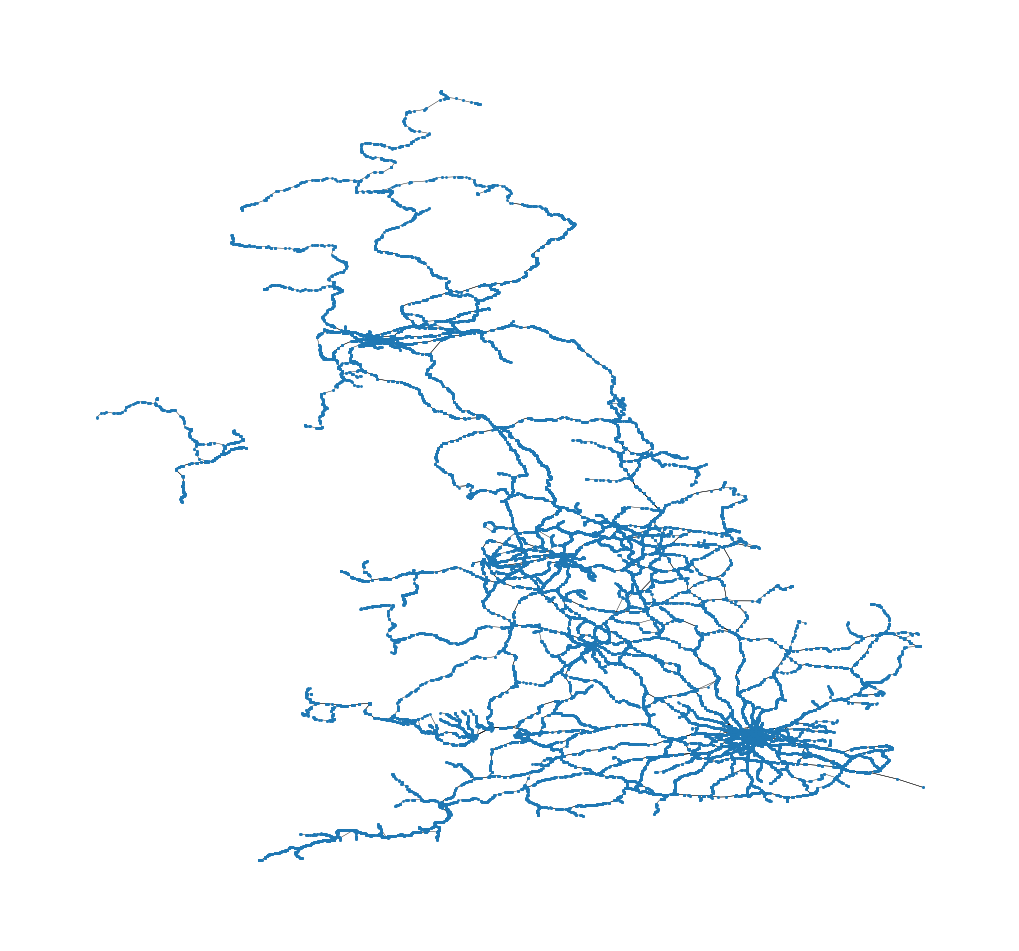

In [177]:
plt.figure(figsize=(10, 12))

pos = {n: (n[0], n[1]) for n in G_connected.nodes()}

nx.draw(
    G_connected,
    pos,
    node_size=1,
    width=0.3,
    edge_color="black"
)

plt.gca().set_aspect("equal")
plt.show()

## We want to remove Northern Ireland because it is not connected to the mainland network in real life

In [178]:
target = np.array([-5.93, 54.60]) #Longitude and latitude of Belfast (Capital of Northern Ireland)

#closest node in the graph
nodes = np.array([np.array(n) for n in G_connected.nodes()])
dists = np.linalg.norm(nodes - target, axis=1)
closest_node = tuple(nodes[dists.argmin()])

print("Closest node is :", closest_node)

#Find and remove the component associated to this point (so removing Northern Ireland)
component_NI = next(comp for comp in nx.connected_components(G_connected) if closest_node in comp)

print("NI component size :", len(component_NI))

G_final = G_connected.copy()
G_final.remove_nodes_from(component_NI)

Closest node is : (-5.9246143, 54.605539)
NI component size : 788


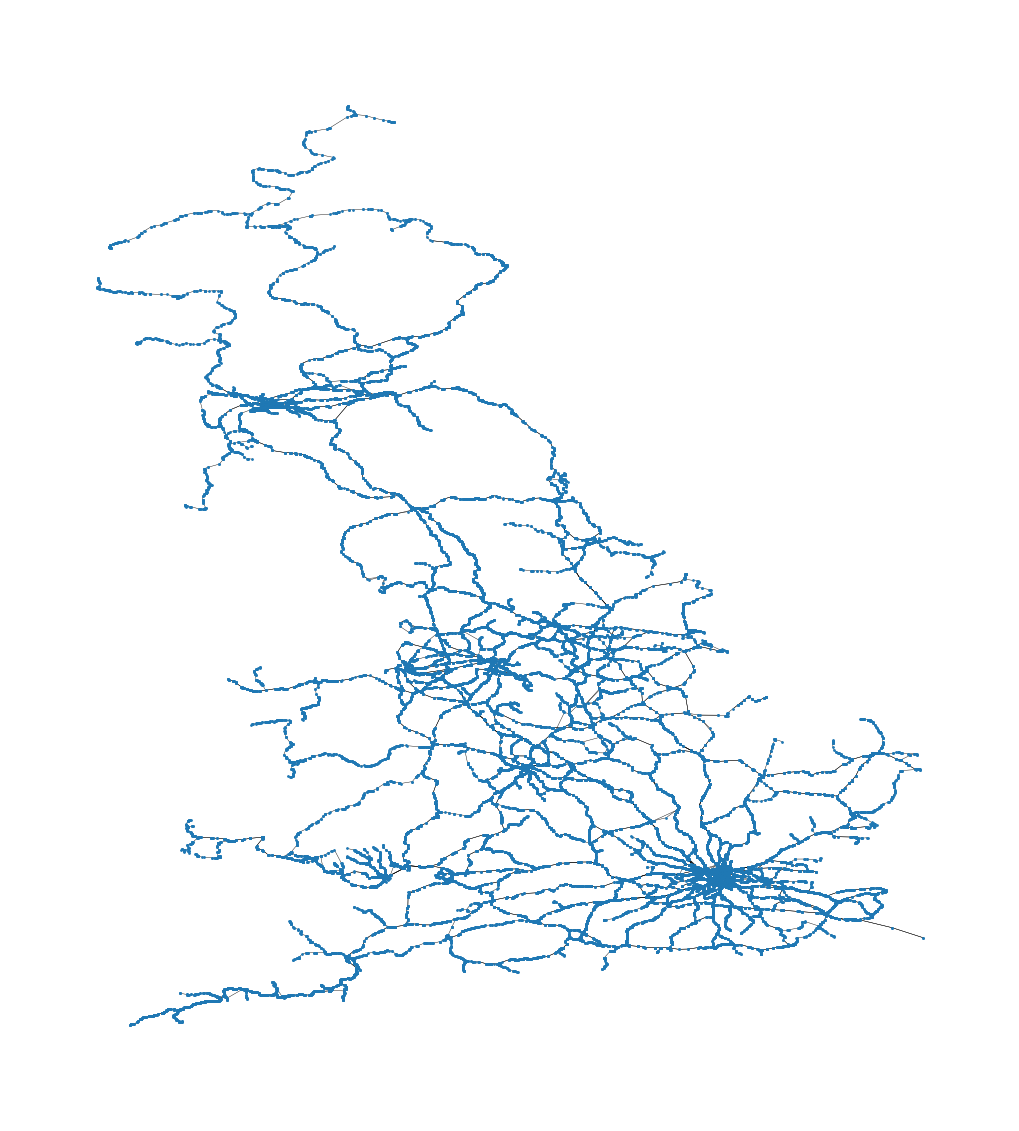

In [179]:
plt.figure(figsize=(10, 12))

pos = {n: (n[0], n[1]) for n in G_final.nodes()}
nx.draw(G_final, pos, node_size=1, width=0.3, edge_color="black")

plt.gca().set_aspect("equal")
plt.show()

In [180]:
m = folium.Map(
    location=[54, -2],
    zoom_start=6,
    tiles="CartoDB Positron"
)

#Add edges
for u, v, d in G_final.edges(data=True):
    if isinstance(u, tuple) and isinstance(v, tuple):
        folium.PolyLine(
            locations=[(u[1], u[0]), (v[1], v[0])],
            color="blue",
            weight=2,
            opacity=0.6
        ).add_to(m)

#Add nodes
for n, d in G_final.nodes(data=True):
    if not (isinstance(n, tuple) and len(n) == 2):
        continue

    lon ,lat = n

    folium.CircleMarker(
        location=[lat, lon],
        radius=1,
        color="red",
        fill=True,
        fill_opacity = 0.5
    ).add_to(m)

m.save("graph.html")
#m

### Is the network now fully connected ? Yes if there is only 1 component

In [181]:
nx.number_connected_components(G_final)

1

### Check the degrees of each node

In [182]:
degrees = [d for _, d in G_final.degree()]
print("min:", np.min(degrees))
print("max:", np.max(degrees))
print("mean:", np.mean(degrees))
print("degree=1:", degrees.count(1))
print("degree=2:", degrees.count(2))
print("degree>=3:", sum(d>=3 for d in degrees))

min: 1
max: 6
mean: 2.0546006983810257
degree=1: 2727
degree=2: 57214
degree>=3: 6212


## Add attributes

In [183]:
stations_in_G = [n for n, d in G.nodes(data=True) if d.get("type") == "station"]
len(stations_in_G)


11696

In [184]:
for n in stations_in_G:
    if n not in G_final:
        G_final.add_node(n)

for n in stations_in_G:
    G_final.nodes[n].update(G.nodes[n])

for n in stations_in_G:
    G_final.nodes[n]["stanox"] = stanox_map.get(n)


In [185]:
[(n, d) for n, d in G_final.nodes(data=True) if isinstance(n, str)][:2]

[('AACHEN',
  {'type': 'station',
   'name': 'Aachen',
   'lat': nan,
   'lon': nan,
   'crs': nan,
   'stanox': '00005'}),
 ('ABCWM',
  {'type': 'station',
   'name': 'Abercwmboi',
   'lat': nan,
   'lon': nan,
   'crs': nan,
   'stanox': '78128'})]

In [186]:
[(n, d) for n, d in G_final.nodes(data=True) if isinstance(n, tuple)][:2]

[((1.1454283, 51.2592228),
  {'type': 'osm_point', 'lon': 1.1454283, 'lat': 51.2592228}),
 ((-2.5807156, 51.4484134),
  {'type': 'osm_point', 'lon': -2.5807156, 'lat': 51.4484134})]

In [187]:
for u, v, d in G.edges(data=True):
    if u in G_final and v in G_final:
        if not G_final.has_edge(u, v):
            G_final.add_edge(u, v, **d)
        else:
            G_final[u][v].update(d)

In [188]:
list(G_final.edges(data=True))[:2]

[((1.1454283, 51.2592228),
  (1.1400766, 51.2606539),
  {'distance': 0.25163964288055435,
   'maxspeed': 90.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'FDM'}),
 ((1.1454283, 51.2592228),
  (1.1456842, 51.2591524),
  {'distance': 0.012086838315614417,
   'maxspeed': 90.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'FDM'})]

## Save graph

In [189]:
#Optionnal
with open("graph.gpickle", "wb") as f:
    pickle.dump(G_final, f)

## Load graph

In [190]:
#Optionnal
with open("graph.gpickle", "rb") as f:
    G_final = pickle.load(f)

====================================================================================
=============================TEST===================================================
====================================================================================

## Area to be tested 

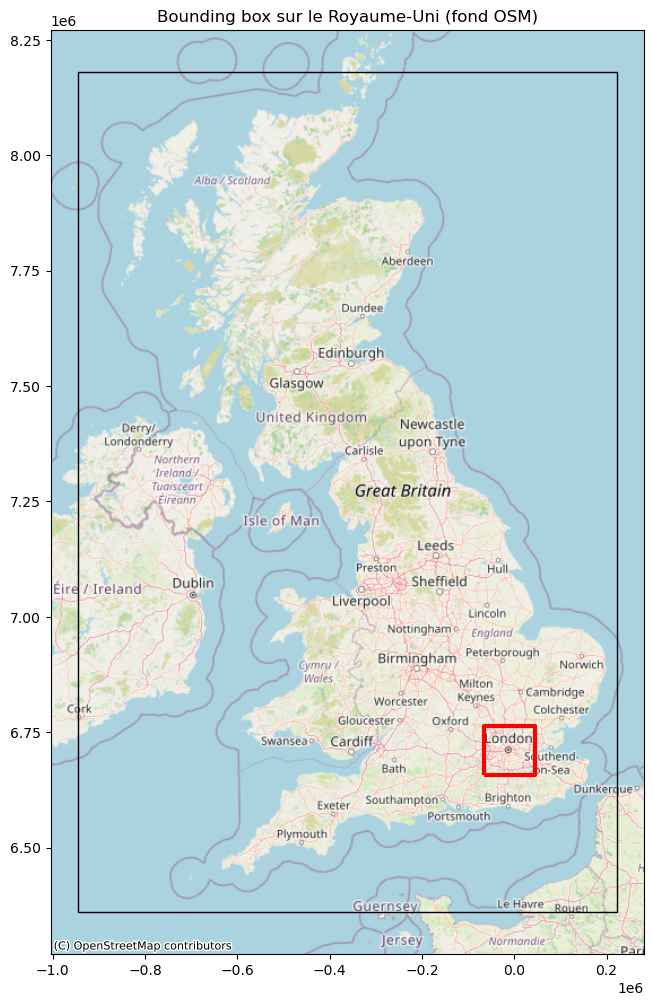

In [269]:

#Bounding box to test (can be modified)
minx, miny = -0.6, 51.2
maxx, maxy = 0.4, 51.8

bbox_poly = box(minx, miny, maxx, maxy)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")

uk_minx, uk_miny = -8.5, 49.5
uk_maxx, uk_maxy = 2.0, 59.0

uk_poly = box(uk_minx, uk_miny, uk_maxx, uk_maxy)
uk_gdf = gpd.GeoDataFrame(geometry=[uk_poly], crs="EPSG:4326")

uk_web = uk_gdf.to_crs(3857)
bbox_web = bbox_gdf.to_crs(3857)

# --- 4) Affichage ---
fig, ax = plt.subplots(figsize=(10, 12))

# UK rectangle (juste pour cadrer la carte)
uk_web.boundary.plot(ax=ax, color="black", linewidth=1)

# bounding box rouge
bbox_web.boundary.plot(ax=ax, color="red", linewidth=3)

# fond de carte OSM
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Bounding box sur le Royaume-Uni (fond OSM)")
plt.show()


## Subgraph

In [277]:
lat_min, lat_max = 51.2, 51.8
lon_min, lon_max = -0.6, 0.4

nodes_to_keep = []

for n, d in G.nodes(data=True):

    lat = d.get("lat")
    lon = d.get("lon")

    if lat is not None and lon is not None:

        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            nodes_to_keep.append(n)

G_london = G.subgraph(nodes_to_keep).copy()

In [278]:
largest_cc = max(nx.connected_components(G_london), key=len)

G_london = G_london.subgraph(largest_cc).copy()

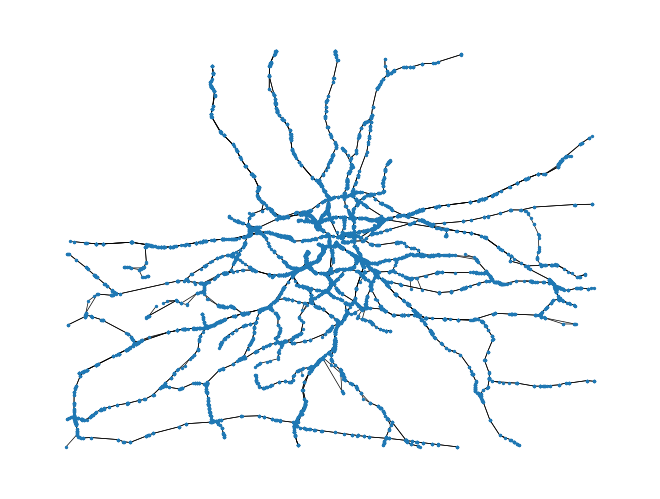

In [271]:
pos = {
    n: (d["lon"], d["lat"])
    for n, d in G_london.nodes(data=True)
    if "lon" in d and "lat" in d
}

nx.draw(
    G_london,
    pos,
    node_size=2,
    width=0.5,
    with_labels=False
)

In [272]:
print("Nodes :", G_london.number_of_nodes())
print("Edges :", G_london.number_of_edges())

Nodes : 10095
Edges : 10454


In [235]:
print(nx.number_connected_components(G_london))

1


In [237]:
degrees = [d for n, d in G_london.degree()]

avg_degree = sum(degrees) / len(degrees)

print(avg_degree)

2.071124318969787


In [246]:
list(G.nodes(data=True))[:2]

[('AACHEN',
  {'type': 'station',
   'name': 'Aachen',
   'lat': nan,
   'lon': nan,
   'crs': nan,
   'stanox': '00005'}),
 ('ABCWM',
  {'type': 'station',
   'name': 'Abercwmboi',
   'lat': nan,
   'lon': nan,
   'crs': nan,
   'stanox': '78128'})]

In [233]:
list(G_london.edges(data=True))[:2]

[((-0.0988616, 51.4973916),
  (-0.0985157, 51.4951534),
  {'distance': 0.15536053947488085,
   'maxspeed': 60.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'HHH'}),
 ((-0.0988616, 51.4973916),
  (-0.099215, 51.4980146),
  {'distance': 0.04565088254080461,
   'maxspeed': 60.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 4,
   'usage': 'main',
   'elr': nan})]

In [319]:
stats_nodes = []

for node, deg in degrees.items():
    d = G_london.nodes[node]
    if "name" in d or "tiploc" in d or "stanox" in d:
        name = d.get("name") or d.get("tiploc") or d.get("stanox")
        stats_nodes.append({'Node': node, 'Name': name, 'Degree': deg})

df_hubs = pd.DataFrame(stats_nodes).sort_values(by='Degree', ascending=False)
print(df_hubs.head(15))


                         Node             Name  Degree
250  (-0.3761431, 51.5061172)         Southall       3
48   (-0.3096752, 51.6782272)        Hatch End       3
332  (-0.1048434, 51.5775144)        Harringay       3
349  (-0.3101476, 51.6786645)          Radlett       3
325  (-0.3940407, 51.5038054)    South Ruislip       3
123   (0.2560191, 51.5589006)        Upminster       3
355  (-0.1477858, 51.4781445)   Battersea Park       3
309  (-0.2886094, 51.5467453)  Wembley Stadium       3
176  (-0.4490181, 51.5070376)     West Ruislip       3
300  (-0.3306069, 51.4499878)       Twickenham       3
394   (0.1908159, 51.4671211)      Slade Green       3
197  (-0.5041515, 51.4326322)          Staines       3
199   (-0.242331, 51.4670629)           Barnes       3
147  (-0.5618082, 51.5090962)   Gerrards Cross       3
240    (-0.27082, 51.4990805)      South Acton       3


# Add name and tiploc

In [287]:
from scipy.spatial import cKDTree
import numpy as np
import math

valid_nodes = []
valid_coords = []

for n in G_london.nodes:
    if n in G.nodes:
        d = G.nodes[n]
        lon = d.get("lon")
        lat = d.get("lat")

        # garder uniquement les coordonnées finies
        if lon is not None and lat is not None and math.isfinite(lon) and math.isfinite(lat):
            valid_nodes.append(n)
            valid_coords.append([lon, lat])

valid_coords = np.array(valid_coords)
tree = cKDTree(valid_coords)

for _, row in df_name_loc.iterrows():
    lon = row["long"]
    lat = row["lat"]

    # ignorer les lignes invalides
    if lon is None or lat is None:
        continue
    if not (math.isfinite(lon) and math.isfinite(lat)):
        continue

    tiploc = row["tiploc"]
    name = row["name"]

    # nearest neighbour dans les nœuds valides
    dist, idx = tree.query([lon, lat])
    nearest_node = valid_nodes[idx]

    # ajouter les attributs dans G_london
    G_london.nodes[nearest_node]["tiploc"] = tiploc
    G_london.nodes[nearest_node]["name"] = name


In [289]:
count_tiploc = sum(
    1 for n, d in G_london.nodes(data=True)
    if "tiploc" in d
)

count_name = sum(
    1 for n, d in G_london.nodes(data=True)
    if "name" in d
)

print("Nœuds avec tiploc :", count_tiploc)
print("Nœuds avec name   :", count_name)
print("Total nœuds       :", G_london.number_of_nodes())


Nœuds avec tiploc : 460
Nœuds avec name   : 463
Total nœuds       : 10095


### Add stanox

In [298]:
df_STAN_TIP.columns

Index(['id', 'NLC', 'STANOX', 'TIPLOC', '3ALPHA', 'UIC', 'NLCDESC',
       'NLCDESC16'],
      dtype='object')

In [300]:
tiploc_to_stanox = {
    row["TIPLOC"]: row["STANOX"]
    for _, row in df_STAN_TIP.iterrows()
    if isinstance(row["TIPLOC"], str)
}

count_added = 0

for n, d in G_london.nodes(data=True):
    tiploc = d.get("tiploc")
    if tiploc in tiploc_to_stanox:
        G_london.nodes[n]["stanox"] = tiploc_to_stanox[tiploc]
        count_added += 1

print("STANOX ajoutés :", count_added)


STANOX ajoutés : 457


In [301]:
count_stanox = sum(
    1 for _, d in G_london.nodes(data=True)
    if "stanox" in d
)

print("Nœuds avec stanox :", count_stanox)
print("Nœuds avec tiploc :", sum("tiploc" in d for _, d in G_london.nodes(data=True)))


Nœuds avec stanox : 462
Nœuds avec tiploc : 460


In [307]:
sample = [
    (n, {k: d[k] for k in ["lon", "lat", "tiploc", "name", "stanox"] if k in d})
    for n, d in G_london.nodes(data=True)
    if "tiploc" in d
][:10]

sample


[('GRVSEND',
  {'lon': 0.36699,
   'lat': 51.441029,
   'tiploc': 'GRVSEND',
   'name': 'Gravesend',
   'stanox': '88721'}),
 ('BLCHSRD',
  {'lon': -0.04123,
   'lat': 51.586143,
   'tiploc': 'BLCHSRD',
   'name': 'Blackhorse Road',
   'stanox': '51555'}),
 ('STMFDHL',
  {'lon': -0.076343,
   'lat': 51.575035,
   'tiploc': 'STMFDHL',
   'name': 'Stamford Hill',
   'stanox': '51961'}),
 ('WDWTOWN',
  {'lon': -0.187679,
   'lat': 51.460812,
   'tiploc': 'WDWTOWN',
   'name': 'Wandsworth Town',
   'stanox': '87153'}),
 ('EPSM',
  {'lon': -0.268756,
   'lat': 51.334339,
   'tiploc': 'EPSM',
   'name': 'Epsom',
   'stanox': '87681'}),
 ((0.1197351, 51.5667313),
  {'lon': 0.1197351,
   'lat': 51.5667313,
   'tiploc': 'GODMAYS',
   'name': 'Goodmayes',
   'stanox': '50412'}),
 ('GNRSBRY',
  {'lon': -0.275766,
   'lat': 51.491814,
   'tiploc': 'GNRSBRY',
   'name': 'Gunnersbury',
   'stanox': '87138'}),
 ('EDNB',
  {'lon': 0.060099,
   'lat': 51.208508,
   'tiploc': 'EDNB',
   'name': 'Edenbri

# Train movement data

In [263]:
movement1 = "data/4E24_TRUST2.csv"
df_movement_first = pd.read_csv(movement1)

In [265]:
df_movement_first.head()

,id,created_unix,msg_type,source_dev_id,user_id,original_data_source,msg_queue_timestamp,source_system_id,event_type,gbtt_timestamp,...,train_service_code,toc_id,loc_stanox,auto_expected,direction_ind,route,planned_event_type,next_report_stanox,line_ind,Datetime
0,652732363,1777628679,3,NaN,NaN,SMART,1777628678000,TRUST,DEPARTURE,NaN,...,54606070,9,51123,True,UP,1.0,DEPARTURE,51122.0,NaN,2026-05-01 10:44:00.000
1,652737063,1777629084,3,FQ42159,NaN,TOPS,1777629084000,TRUST,DEPARTURE,1.777632e+12,...,54606070,9,51127,False,NaN,NaN,DEPARTURE,51129.0,NaN,2026-05-01 10:37:00.000
2,652743586,1777629641,3,NaN,NaN,SMART,1777629640000,TRUST,DEPARTURE,NaN,...,54606070,9,51121,True,UP,1.0,DEPARTURE,51203.0,U,2026-05-01 11:00:00.000
3,652750813,1777630264,3,NaN,NaN,SMART,1777630263000,TRUST,ARRIVAL,NaN,...,54606070,9,51203,True,NaN,0.0,ARRIVAL,51311.0,NaN,2026-05-01 11:11:00.000
4,652751402,1777630312,3,NaN,NaN,SMART,1777630310000,TRUST,DEPARTURE,NaN,...,54606070,9,51203,True,UP,1.0,DEPARTURE,51311.0,U,2026-05-01 11:11:00.000


In [266]:
df_movement_first.columns

Index(['id', 'created_unix', 'msg_type', 'source_dev_id', 'user_id',
       'original_data_source', 'msg_queue_timestamp', 'source_system_id',
       'event_type', 'gbtt_timestamp', 'original_loc_stanox',
       'planned_timestamp', 'timetable_variation', 'original_loc_timestamp',
       'current_train_id', 'delay_monitoring_point', 'next_report_run_time',
       'reporting_stanox', 'actual_timestamp', 'correction_ind',
       'event_source', 'train_file_address', 'platform', 'division_code',
       'train_terminated', 'train_id', 'offroute_ind', 'variation_status',
       'train_service_code', 'toc_id', 'loc_stanox', 'auto_expected',
       'direction_ind', 'route', 'planned_event_type', 'next_report_stanox',
       'line_ind', 'Datetime'],
      dtype='object')

In [320]:
# On crée un ensemble (set) de tous les STANOX présents dans ton graphe de Londres
# On utilise un set car la recherche est beaucoup plus rapide qu'avec une liste
stanox_london = {
    str(d['stanox']).zfill(5) 
    for n, d in G_london.nodes(data=True) 
    if 'stanox' in d and pd.notna(d['stanox'])
}

print(f"Nombre de STANOX uniques dans G_london : {len(stanox_london)}")

Nombre de STANOX uniques dans G_london : 458


In [321]:
# 1. On s'assure que la colonne loc_stanox est au bon format (String, 5 chiffres)
df_movement_first['loc_stanox'] = df_movement_first['loc_stanox'].astype(str).str.strip().str.zfill(5)

# 2. On ne garde que les lignes dont le STANOX est dans notre liste londonienne
df_movements_london = df_movement_first[df_movement_first['loc_stanox'].isin(stanox_london)].copy()

# 3. Résultat
print(f"Mouvements initiaux : {len(df_movement_first)}")
print(f"Mouvements à Londres : {len(df_movements_london)}")
print(f"Nombre de trains uniques restant : {df_movements_london['train_id'].nunique()}")

Mouvements initiaux : 498
Mouvements à Londres : 134
Nombre de trains uniques restant : 6
